https://velog.io/@kungsboy/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D-12-03.%EC%95%99%EC%83%81%EB%B8%94Ensemble-Boosting-%EB%AA%A8%EB%8D%B8-AdaBoost-Gradient-Boosting-%EC%98%88%EC%A0%9C-t1gl1ih1

[AdaBoost  ](https://humankind.tistory.com/17)

https://velog.io/@gyurili/ML-%EB%B6%80%EC%8A%A4%ED%8C%85-%EC%95%8C%EA%B3%A0%EB%A6%AC%EC%A6%98Boosting%EC%9D%B4%EB%9E%80-AdaBoost-Gradient-Boosting-XGBoost-LightGBM

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

base_model = DecisionTreeClassifier(max_depth=1)

model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [3]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_test, pred, name):
    print(f"\n📊 {name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred, average='macro'))
    print("Recall:", recall_score(y_test, pred, average='macro'))
    print("F1:", f1_score(y_test, pred, average='macro'))

evaluate(y_test, pred, "AdaBoost")
evaluate(y_test, gb_pred, "Gradient Boosting")


📊 AdaBoost
Accuracy: 0.9333333333333333
Precision: 0.9326599326599326
Recall: 0.9326599326599326
F1: 0.9326599326599326

📊 Gradient Boosting
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


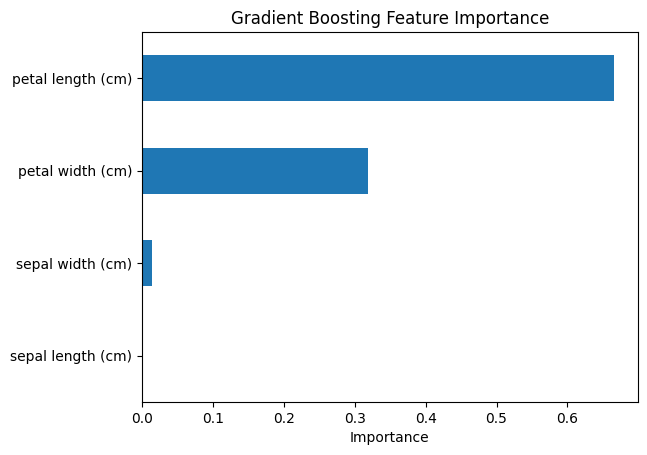

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(gb_model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.show()
